In [1]:
import pandas as pd
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt 
import umap
import hdbscan
import seaborn as sns

c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cols = ['year','Gend3', 'Disab3', 'Age9', 'Relig7', 'Orient4', 'Educ6', 'Eth7', 'DVBMI', 'VolAny', 'NSSEC5', 'DURATION_SPORTCOUNT_A01', 'MEMS7_IN_SPORTCOUNT_A01', 'MEMS7_OUT_SPORTCOUNT_A01', 'MEMS7_ALL']
categorical_cols = ['Gend3', 'Disab3', 'Age9', 'Relig7', 'Orient4', 'Educ6', 'Eth7', 'VolAny', 'NSSEC5']
path = r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\exploration_data\master.csv'
df = pd.read_csv(path, usecols=cols)
df = df[df['year'] == '2022 - 2023']
len(df)

16748

In [3]:
df = df.dropna()
len(df)

4266

In [4]:
df['MEMS7_ALL'].describe()

count     4266.000000
mean       813.317569
std       1218.053331
min          0.000000
25%        120.000000
50%        450.000000
75%       1038.750000
max      23962.500000
Name: MEMS7_ALL, dtype: float64

<Axes: >

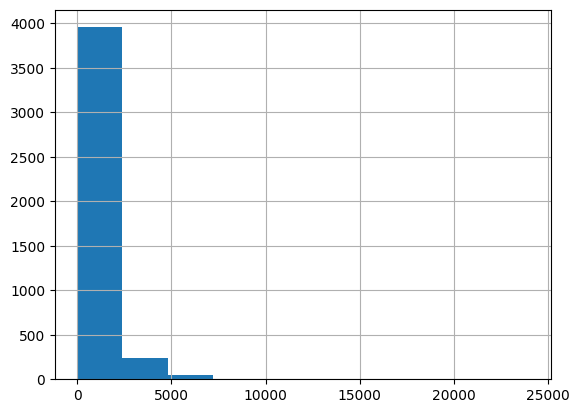

In [5]:
df['MEMS7_ALL'].hist()

In [6]:
exclude_cols = [
    'DURATION_SPORTCOUNT_A01',
    'MEMS7_IN_SPORTCOUNT_A01',
    'MEMS7_OUT_SPORTCOUNT_A01',
    'year'
]
p_cols = []
for i in cols:
    if i in exclude_cols:
        continue
    p_cols.append(i)

print(p_cols)

['Gend3', 'Disab3', 'Age9', 'Relig7', 'Orient4', 'Educ6', 'Eth7', 'DVBMI', 'VolAny', 'NSSEC5', 'MEMS7_ALL']


In [7]:
df = pd.get_dummies(df[p_cols], columns = categorical_cols)
df.head()

,DVBMI,MEMS7_ALL,Gend3_1.0,Gend3_2.0,Gend3_3.0,Disab3_1.0,Disab3_2.0,Disab3_3.0,Age9_2.0,Age9_3.0,...,Eth7_4.0,Eth7_5.0,Eth7_6.0,Eth7_7.0,VolAny_0.0,VolAny_1.0,NSSEC5_1.0,NSSEC5_2.0,NSSEC5_3.0,NSSEC5_4.0
4,29.270718,0.00,True,False,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
13,24.196585,240.00,False,True,False,False,False,True,False,False,...,True,False,False,False,True,False,False,False,False,True
18,26.209758,0.00,False,True,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
26,20.343495,1080.00,False,True,False,True,False,False,False,True,...,False,False,False,False,False,True,True,False,False,False
28,25.384306,318.75,False,True,False,False,True,False,False,False,...,False,False,False,False,True,False,True,False,False,False


In [8]:
print(df.values)

[[29.270718309549952 0.0 True ... False True False]
 [24.196585085555554 240.0 False ... False False True]
 [26.209758145330383 0.0 False ... True False False]
 ...
 [20.17757693977515 360.0 False ... True False False]
 [26.040952824758094 1080.0 True ... False False False]
 [26.47210743801653 865.0 True ... False False False]]


In [9]:
scaler = StandardScaler()
X = df.values
X_scaled = scaler.fit_transform(X)
pca = PCA()
emb = pca.fit_transform(X_scaled)
exp_var = pca.explained_variance_ratio_
print(np.cumsum(exp_var))

[0.0675491  0.12326242 0.17454209 0.22415395 0.26907718 0.3096432
 0.34731047 0.38081475 0.41230768 0.44175369 0.470504   0.49795923
 0.52527583 0.55190658 0.57797727 0.60318299 0.62826107 0.65269156
 0.67672171 0.70041019 0.7237817  0.74671519 0.76882648 0.79077076
 0.81230776 0.8337629  0.8546468  0.87524273 0.89471038 0.91400617
 0.93231453 0.94997638 0.96702657 0.98354747 0.9936149  1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.        ]


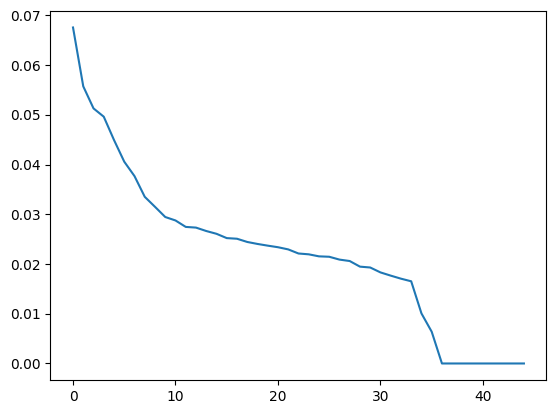

In [10]:
plt.plot(exp_var)

In [11]:
print(exp_var)
pca.components_[:2]

[6.75490977e-02 5.57133200e-02 5.12796753e-02 4.96118553e-02
 4.49232358e-02 4.05660110e-02 3.76672750e-02 3.35042765e-02
 3.14929341e-02 2.94460081e-02 2.87503069e-02 2.74552362e-02
 2.73165936e-02 2.66307563e-02 2.60706884e-02 2.52057223e-02
 2.50780768e-02 2.44304899e-02 2.40301529e-02 2.36884730e-02
 2.33715154e-02 2.29334922e-02 2.21112832e-02 2.19442809e-02
 2.15370021e-02 2.14551440e-02 2.08838956e-02 2.05959286e-02
 1.94676522e-02 1.92957952e-02 1.83083554e-02 1.76618514e-02
 1.70501935e-02 1.65208988e-02 1.00674225e-02 6.38510394e-03
 7.83183359e-17 3.56265063e-17 1.47958957e-17 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00]


array([[-0.08658932,  0.03960303,  0.09488749, -0.09017366, -0.03784838,
        -0.15500965, -0.02813404,  0.13844128, -0.20623583,  0.16832366,
         0.11945757,  0.004567  , -0.08823544, -0.09504612, -0.15467564,
        -0.00945047,  0.01675048,  0.02099647, -0.09851492, -0.03463106,
        -0.0245156 ,  0.20740173, -0.06209603,  0.0750842 ,  0.01839806,
        -0.01934696,  0.4538933 , -0.23251059, -0.28206825, -0.08209167,
        -0.09730293, -0.14207431,  0.01310978,  0.0781714 , -0.04046765,
        -0.12058776,  0.04928017,  0.00906811, -0.03123371, -0.01916647,
         0.01916647,  0.42732072, -0.23805325, -0.20932678, -0.22612934],
       [-0.09426443, -0.01365275,  0.11200353, -0.10838801, -0.02880199,
        -0.16445019, -0.24319261,  0.31524818,  0.14521873,  0.04010472,
         0.13410912,  0.00356324, -0.14981821, -0.17245898, -0.15975536,
         0.03808518,  0.29126517, -0.04644036,  0.29960855,  0.11891255,
         0.0099837 , -0.16057066,  0.13633859, -0.

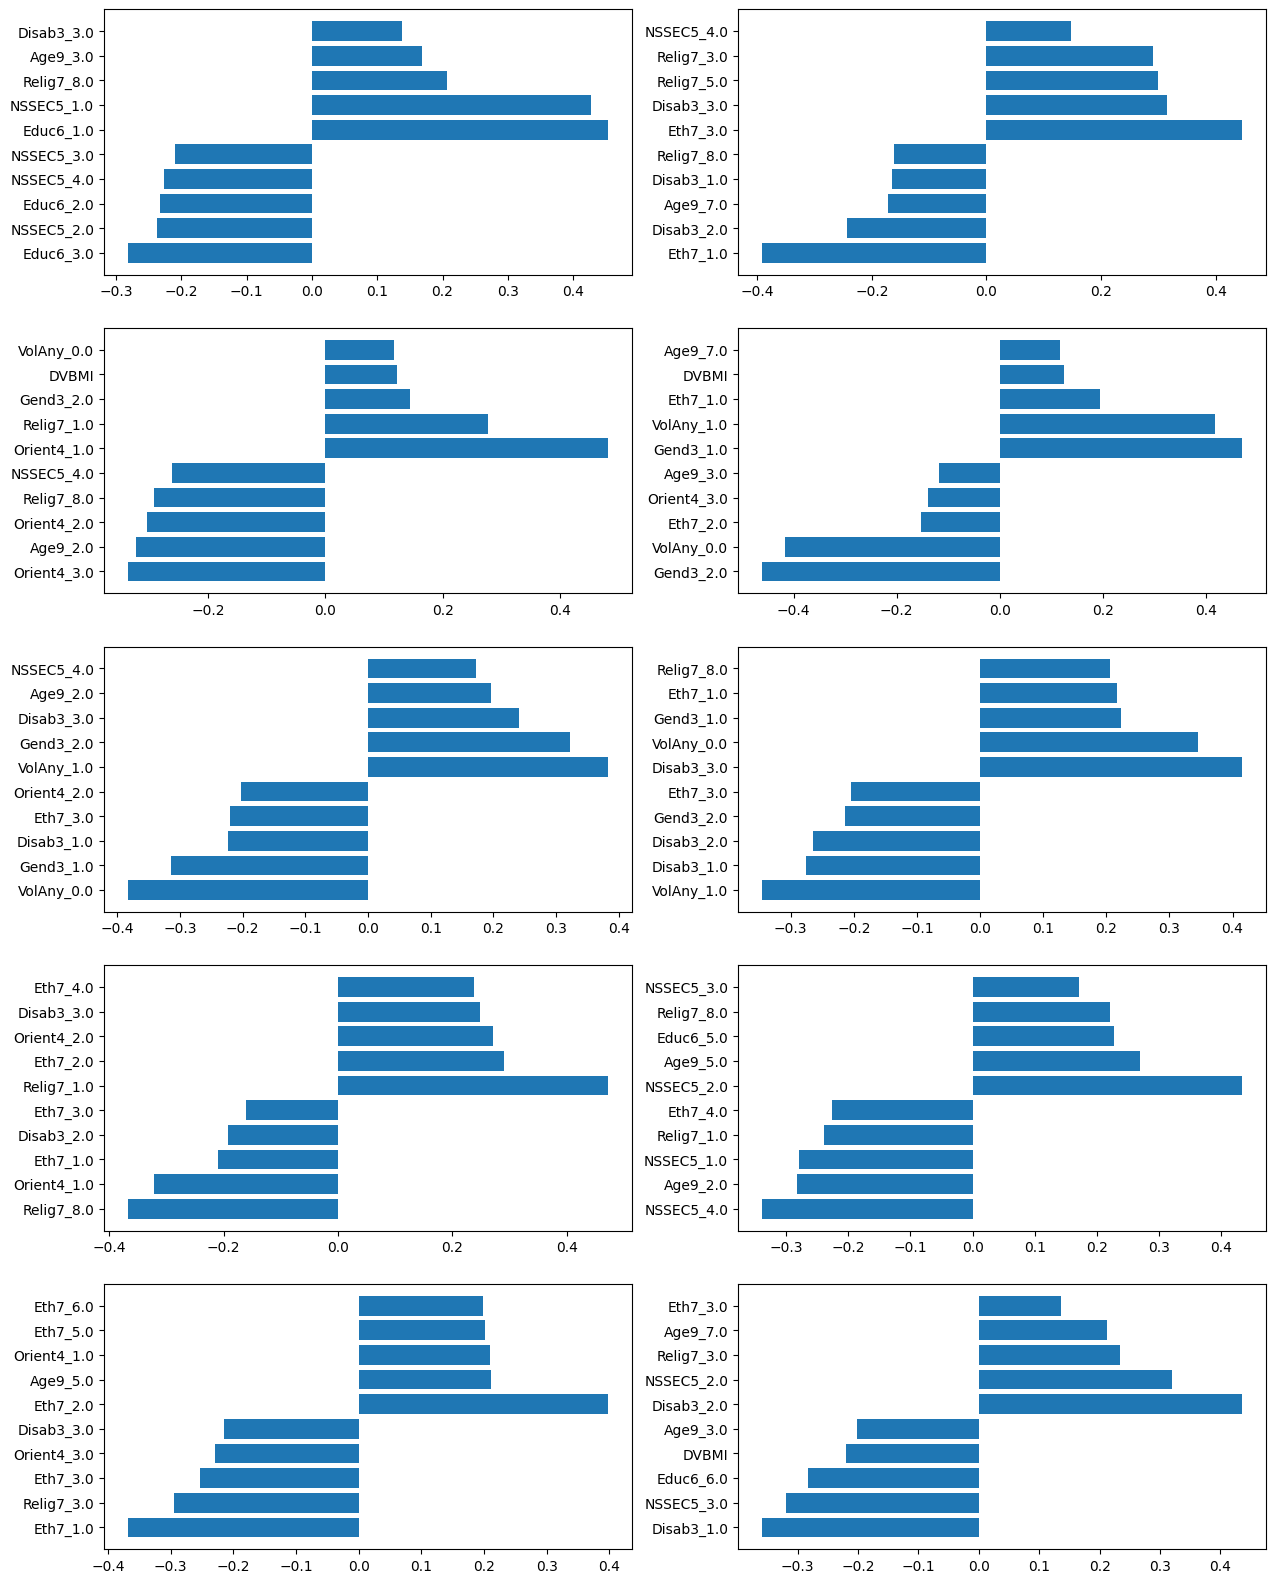

In [12]:
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

for i in range(10):
    loadings = pd.Series(pca.components_[i], index=df.columns)
    # combined = pd.concat([series.sort_values().head(5), series.sort_values(ascending=False).head(5)])
    combined = pd.concat([loadings.sort_values().head(5), loadings.sort_values(ascending=False).head(5)])
    axes[i].barh(combined.index, combined.values)
  


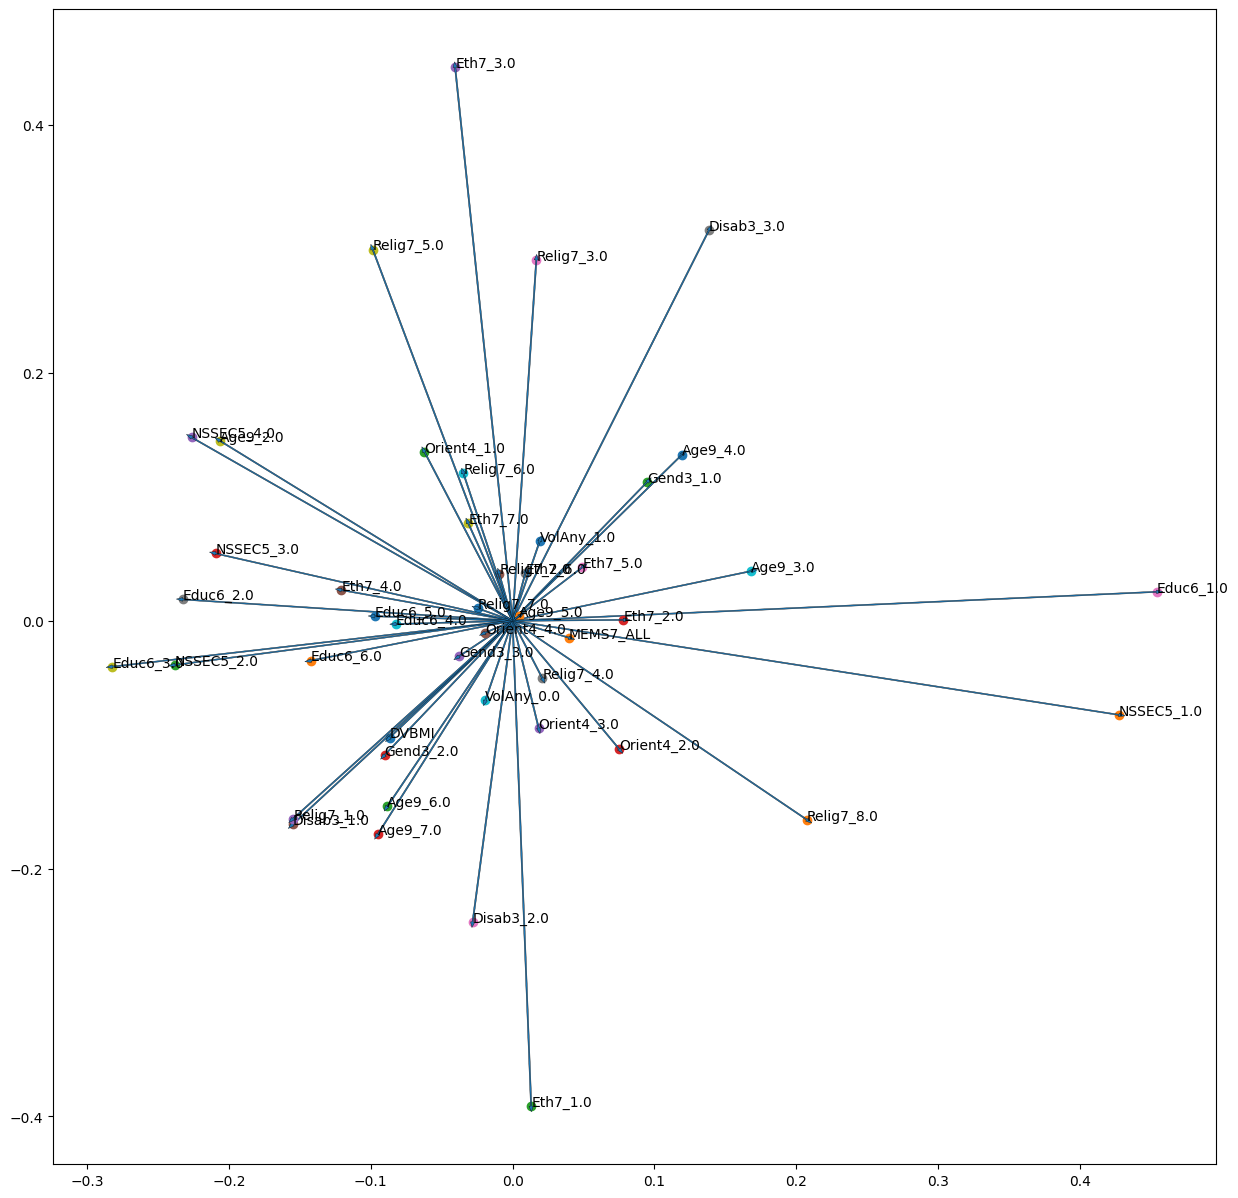

In [13]:
plt.figure(figsize=(15,15))
loadings = pca.components_
xs = loadings[0]
ys = loadings[1]
pca1 = emb[:,0]
pca2 = emb[:,1]
feature_names = df.columns
for i, names in enumerate(feature_names):
    plt.scatter(xs[i], ys[i])
    plt.arrow(
        0, 0, 
        xs[i],
        ys[i],
        linewidth = 0.25
    )
    plt.text(xs[i], ys[i], names)


In [14]:
emb.shape

(4266, 45)

In [15]:
emb.shape[1]

45

In [16]:
pca_df_cols = [f'PCA{i+1}' for i in range(emb.shape[1])]
pca_df = pd.DataFrame(emb, columns = pca_df_cols)
print(pca_df_cols)

['PCA1', 'PCA2', 'PCA3', 'PCA4', 'PCA5', 'PCA6', 'PCA7', 'PCA8', 'PCA9', 'PCA10', 'PCA11', 'PCA12', 'PCA13', 'PCA14', 'PCA15', 'PCA16', 'PCA17', 'PCA18', 'PCA19', 'PCA20', 'PCA21', 'PCA22', 'PCA23', 'PCA24', 'PCA25', 'PCA26', 'PCA27', 'PCA28', 'PCA29', 'PCA30', 'PCA31', 'PCA32', 'PCA33', 'PCA34', 'PCA35', 'PCA36', 'PCA37', 'PCA38', 'PCA39', 'PCA40', 'PCA41', 'PCA42', 'PCA43', 'PCA44', 'PCA45']


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


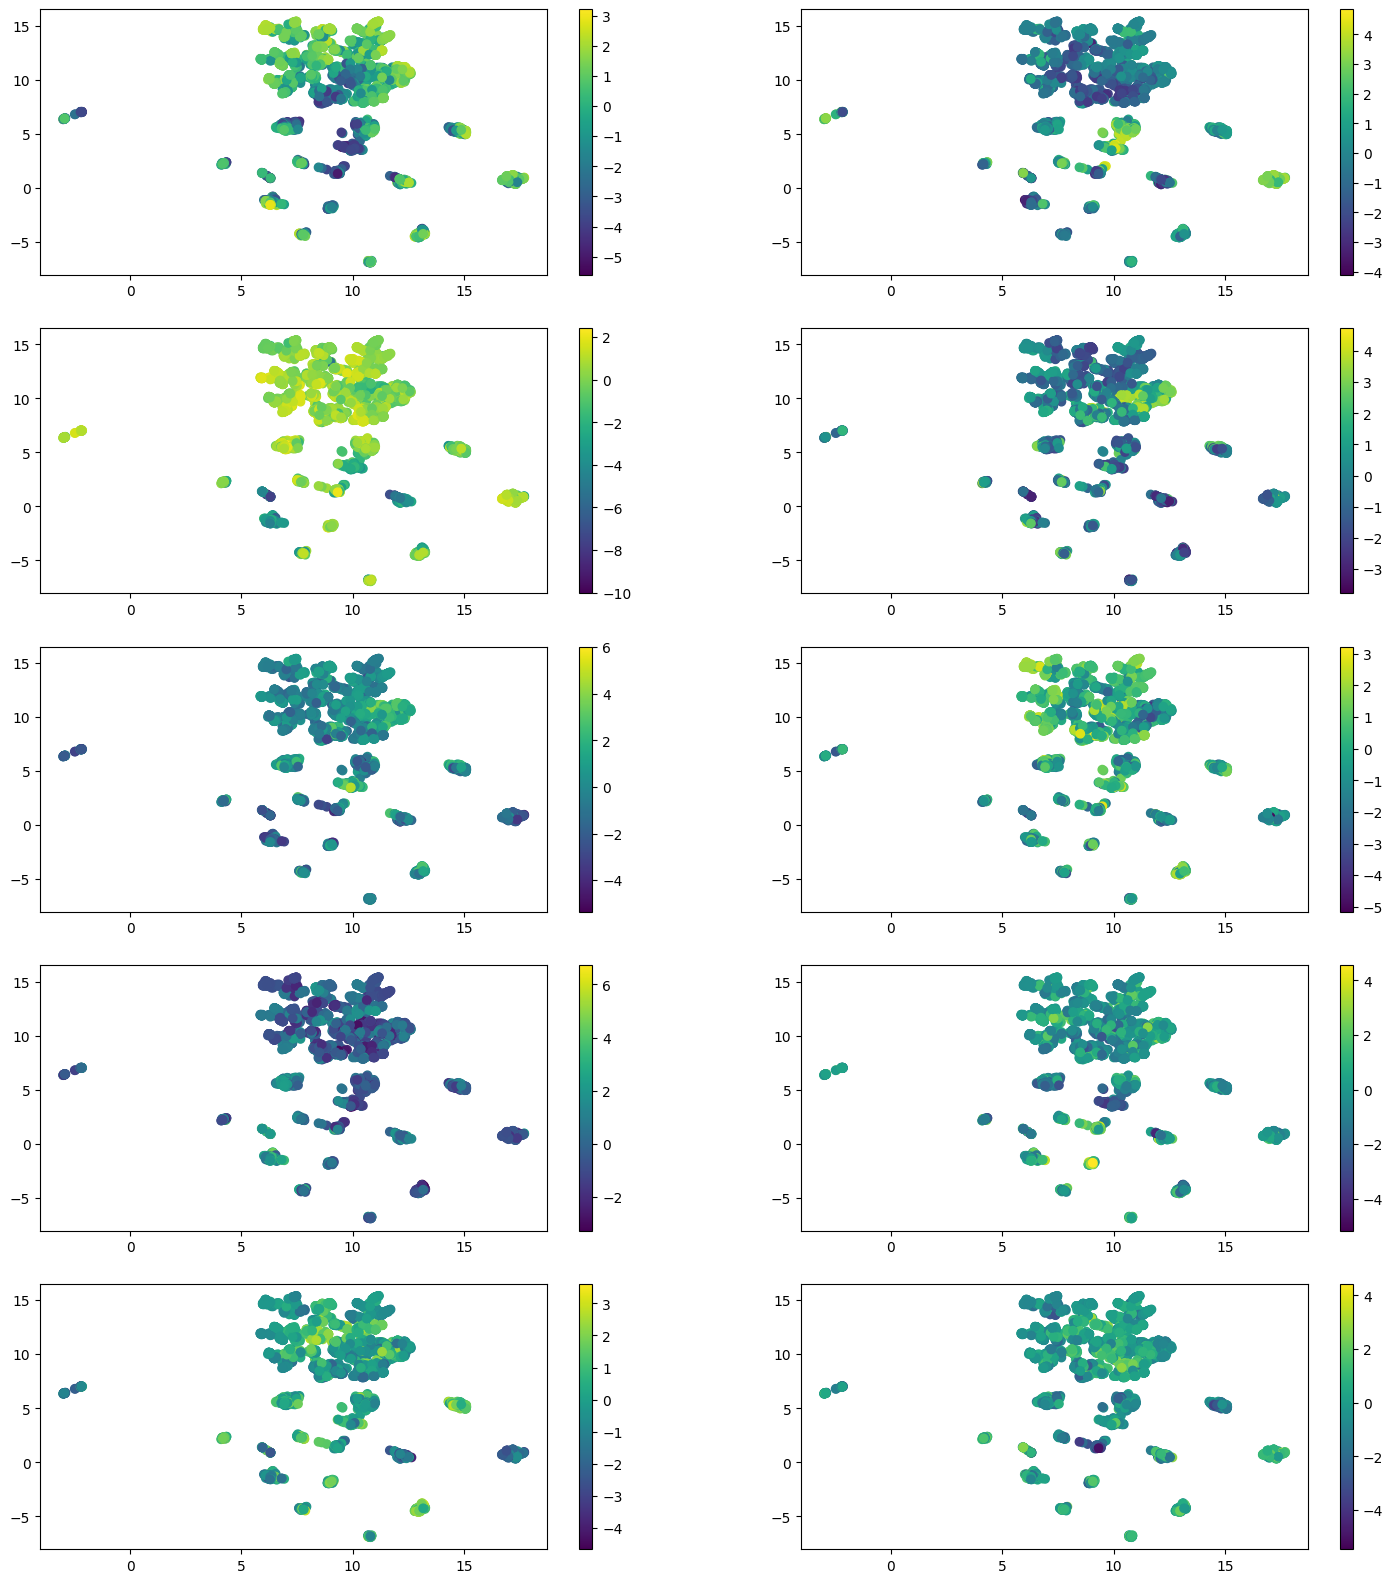

In [17]:
reduce = umap.UMAP(n_neighbors = 50, min_dist=0.1, random_state=42)
scaler = StandardScaler()
X = df.values
X_scaled = scaler.fit_transform(X)
umap_emb = reduce.fit_transform(X_scaled)
fig, axes = plt.subplots(5,2, figsize=(18,20))
axes = axes.flatten()
for i in range(10):
    output = axes[i].scatter(
        umap_emb[:,0], 
        umap_emb[:,1],
        c=pca_df[pca_df_cols[i]]
    )
    plt.colorbar(output, ax=axes[i])

c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


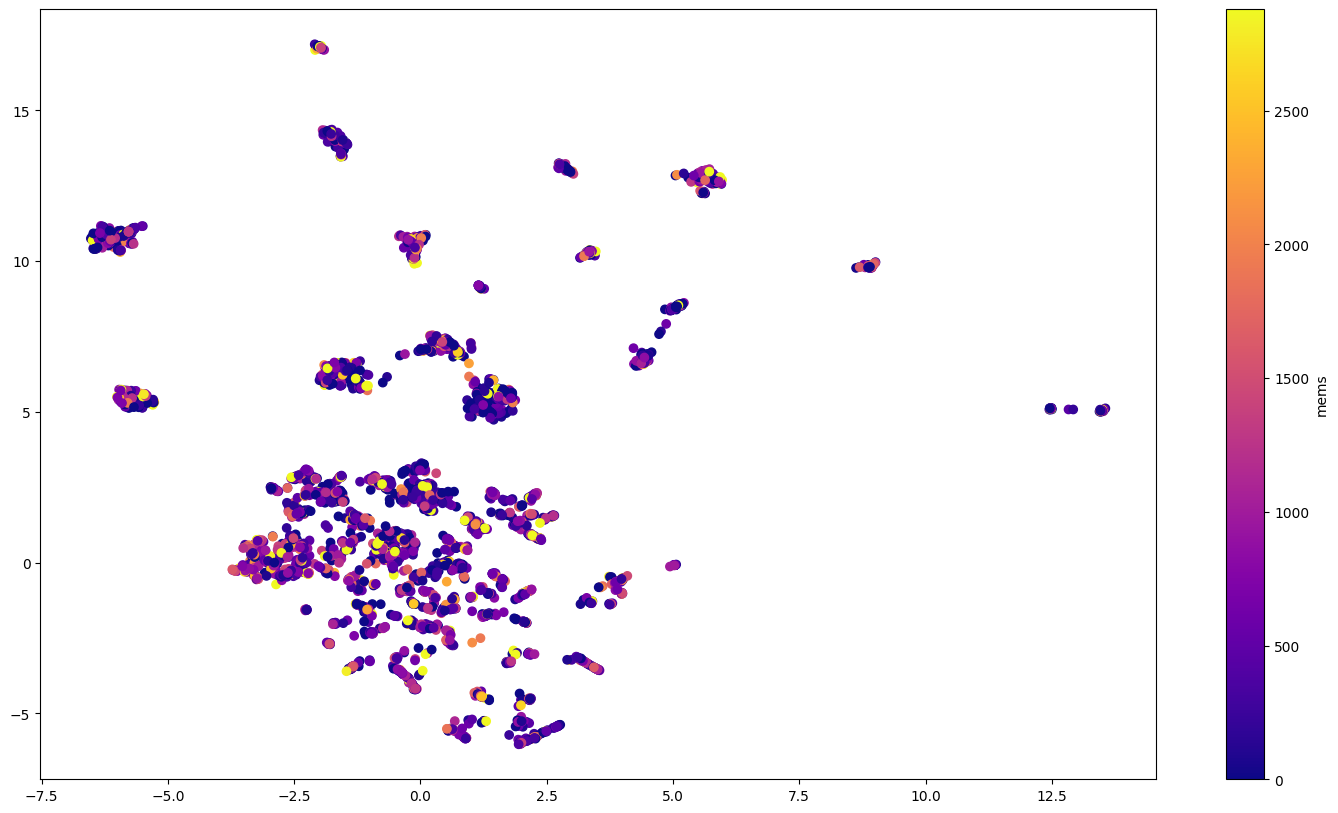

In [18]:
cols = [c for c in df.columns if c != 'MEMS7_ALL']
demo = df[cols]
scaler = StandardScaler()
X = demo.values
X_scaled = scaler.fit_transform(X)
reduce = umap.UMAP(n_neighbors = 50, min_dist=0.1, random_state = 42)
emb = reduce.fit_transform(X_scaled)
mems = df['MEMS7_ALL'].values
plt.figure(figsize=(18,10))
plt.scatter(emb[:,0], emb[:,1], c=mems, cmap='plasma', vmax=np.percentile(mems, 95))
plt.colorbar(label='mems')

In [19]:
i = 0
for m in mems:
    if m >10000:
        i+=1
print(i)
print(len(mems))

8
4266


(array([952., 293., 270., 243., 209., 213., 206., 179., 120., 141., 126.,
        114., 133., 117.,  66.,  90.,  59.,  47.,  54.,  31.,  41.,  50.,
         35.,  30.,  38.,  22.,  22.,  22.,  18.,  16.,  22.,  22.,  12.,
         17.,  12.,   9.,  17.,   8.,   9.,  15.,  11.,   7.,  10.,   4.,
          5.,   5.,   6.,   5.,   5.,   7.,   3.,   4.,   3.,   2.,   3.,
          4.,   0.,   8.,   7.,   1.,   2.,   4.,   1.,   4.,   3.,   1.,
          1.,   2.,   2.,   1.,   1.,   1.,   2.,   4.,   0.,   2.,   1.,
          2.,   4.,   2.,   3.,   1.,   1.,   0.,   2.,   0.,   2.,   1.,
          0.,   0.,   1.,   0.,   1.,   2.,   0.,   2.,   0.,   0.,   0.,
          0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0., 

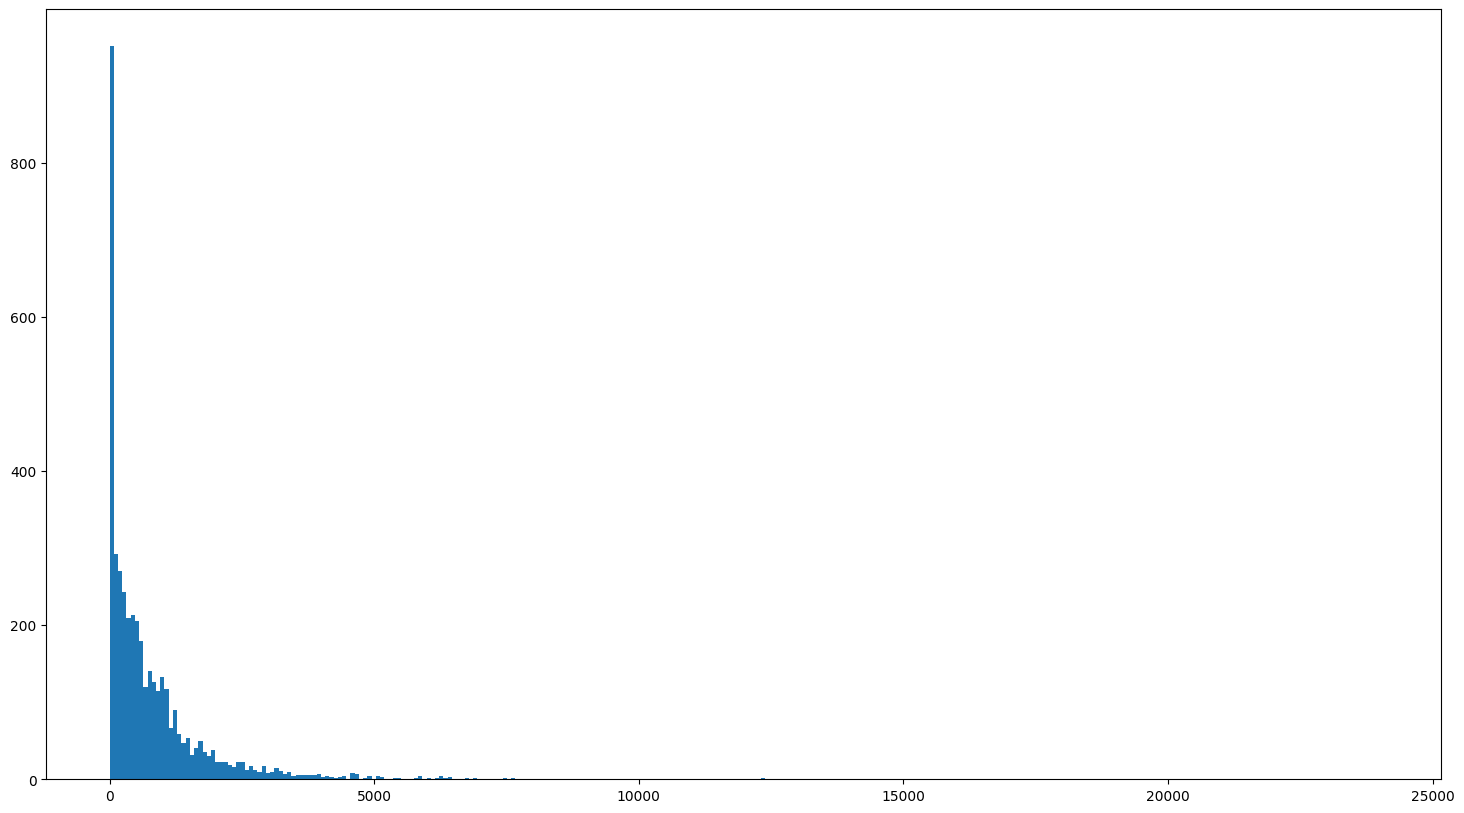

In [20]:
plt.figure(figsize=(18,10))
plt.hist(df['MEMS7_ALL'], bins=300)

In [21]:
def gen_clusters(emb, min_cluster_size) -> pd.DataFrame:
    c = hdbscan.HDBSCAN(min_cluster_size = min_cluster_size)
    labels = c.fit_predict(emb)
    df = pd.DataFrame({
        'umap_x' : emb[:, 0],
        'umap_y' : emb[:, 1],
        'labels' : labels
    })
    return df, emb, labels
def do_umap(df_values, num_neighbors : int = 15, min_dist : float = 0.1, random_state: int = 42):
    reduce = umap.UMAP(n_neighbors = num_neighbors, min_dist=min_dist, random_state = random_state)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_values)
    emb = reduce.fit_transform(X_scaled)
    return emb


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


HDBSCAN has identified 4266 clusters


C:\Users\fergu\AppData\Local\Temp\ipykernel_44624\2030823467.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


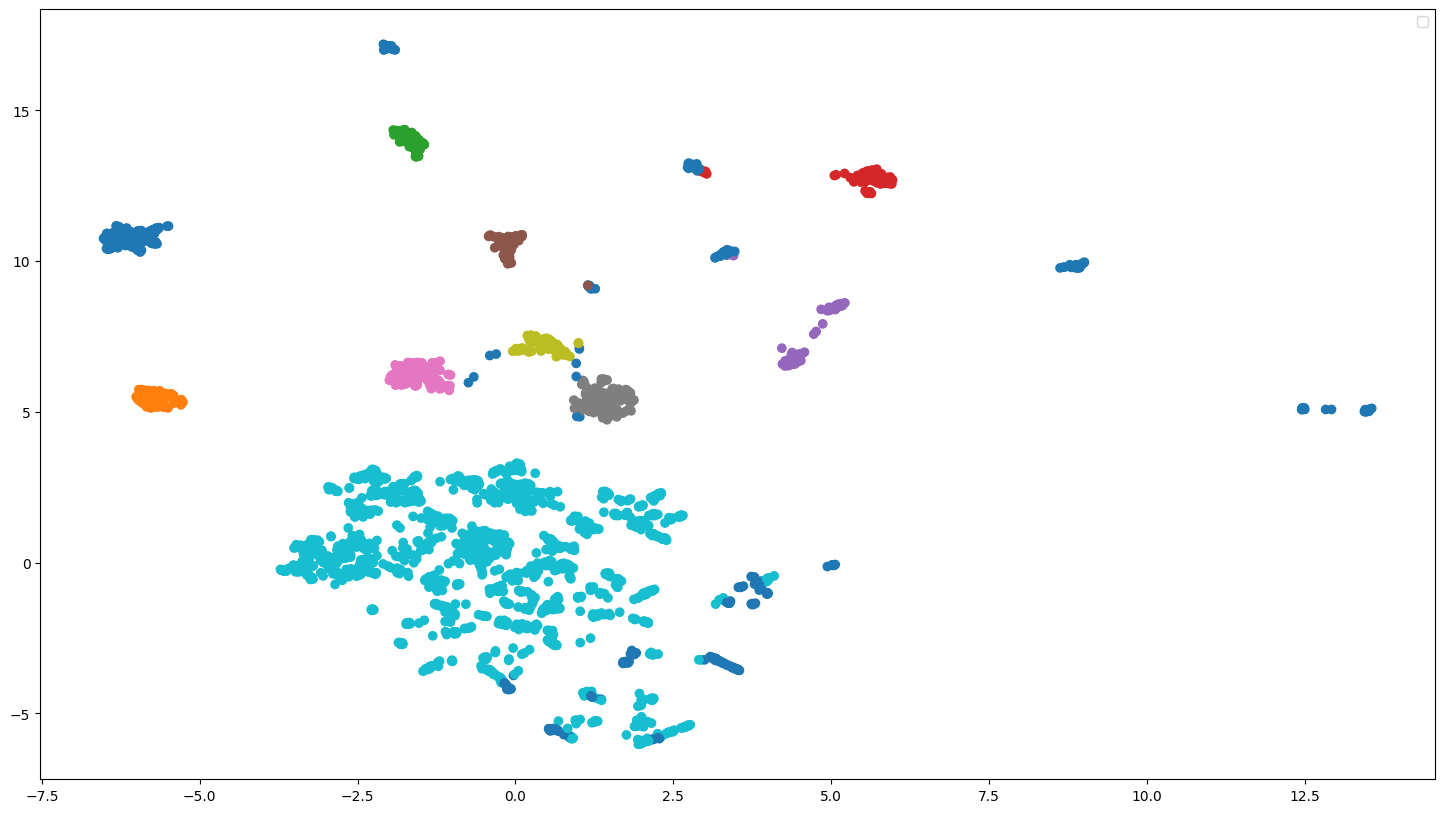

In [22]:
emb = do_umap(demo, num_neighbors = 50, min_dist=0.1, random_state =42)
cluster_df, emb, labels = gen_clusters(emb, min_cluster_size = 100)
print(f'HDBSCAN has identified {len(labels)} clusters')
plt.figure(figsize=(18,10))
plt.scatter(emb[:,0], emb[:,1], c=labels, cmap='tab10')
plt.legend()


<Axes: >

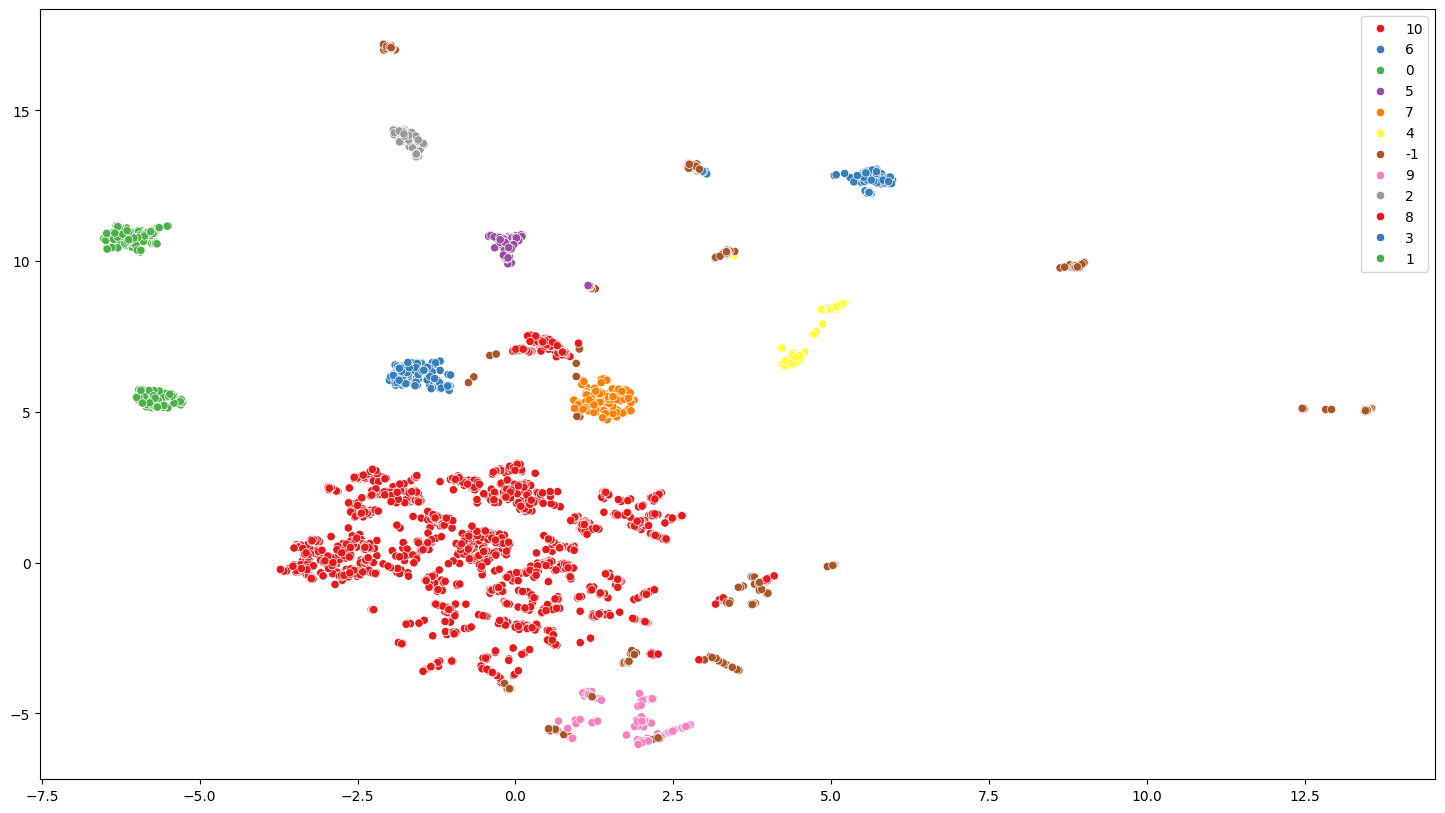

In [23]:
plt.figure(figsize=(18,10))
sns.scatterplot(
    x=emb[:,0],
    y=emb[:,1],
    hue = labels.astype(str),
    palette='Set1'

)

In [24]:
demo['labels'] = labels
demo.head()

,DVBMI,Gend3_1.0,Gend3_2.0,Gend3_3.0,Disab3_1.0,Disab3_2.0,Disab3_3.0,Age9_2.0,Age9_3.0,Age9_4.0,...,Eth7_5.0,Eth7_6.0,Eth7_7.0,VolAny_0.0,VolAny_1.0,NSSEC5_1.0,NSSEC5_2.0,NSSEC5_3.0,NSSEC5_4.0,labels
4,29.270718,True,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,10
13,24.196585,False,True,False,False,False,True,False,False,True,...,False,False,False,True,False,False,False,False,True,6
18,26.209758,False,True,False,False,False,True,False,False,False,...,False,False,False,False,True,False,True,False,False,0
26,20.343495,False,True,False,True,False,False,False,True,False,...,False,False,False,False,True,True,False,False,False,5
28,25.384306,False,True,False,False,True,False,False,False,True,...,False,False,False,True,False,True,False,False,False,0


In [25]:
cols = ['year','Gend3', 'Disab3', 'Age9', 'Relig7', 'Orient4', 'Educ6', 'Eth7', 'DVBMI', 'VolAny', 'NSSEC5', 'DURATION_SPORTCOUNT_A01', 'MEMS7_IN_SPORTCOUNT_A01', 'MEMS7_OUT_SPORTCOUNT_A01', 'MEMS7_ALL']
df = pd.read_csv(path, usecols=cols)
df = df.dropna()
df = df[df['year'] == '2022 - 2023']
df['labels'] = labels
df.head()

,Age9,Disab3,Educ6,Eth7,Gend3,NSSEC5,Orient4,Relig7,DVBMI,MEMS7_ALL,VolAny,DURATION_SPORTCOUNT_A01,MEMS7_IN_SPORTCOUNT_A01,MEMS7_OUT_SPORTCOUNT_A01,year,labels
4,6.0,1.0,1.0,1.0,1.0,3.0,1.0,1.0,29.270718,0.00,1.0,0.00,0.0,0.00,2022 - 2023,10
13,4.0,3.0,1.0,4.0,2.0,4.0,1.0,1.0,24.196585,240.00,0.0,120.00,0.0,240.00,2022 - 2023,6
18,5.0,3.0,1.0,3.0,2.0,2.0,1.0,3.0,26.209758,0.00,1.0,30.00,0.0,0.00,2022 - 2023,0
26,3.0,1.0,1.0,2.0,2.0,1.0,3.0,1.0,20.343495,1080.00,1.0,1350.00,480.0,600.00,2022 - 2023,5
28,4.0,2.0,1.0,3.0,2.0,1.0,1.0,3.0,25.384306,318.75,0.0,581.25,225.0,93.75,2022 - 2023,0


In [26]:
x = df.groupby('labels')['MEMS7_ALL'].mean()
x

labels
-1      806.172231
 0      662.340796
 1      878.696552
 2      605.009766
 3     1027.171569
 4      556.812865
 5      968.016304
 6      795.408967
 7      481.809585
 8     1236.101145
 9      900.888365
 10     832.682650
Name: MEMS7_ALL, dtype: float64

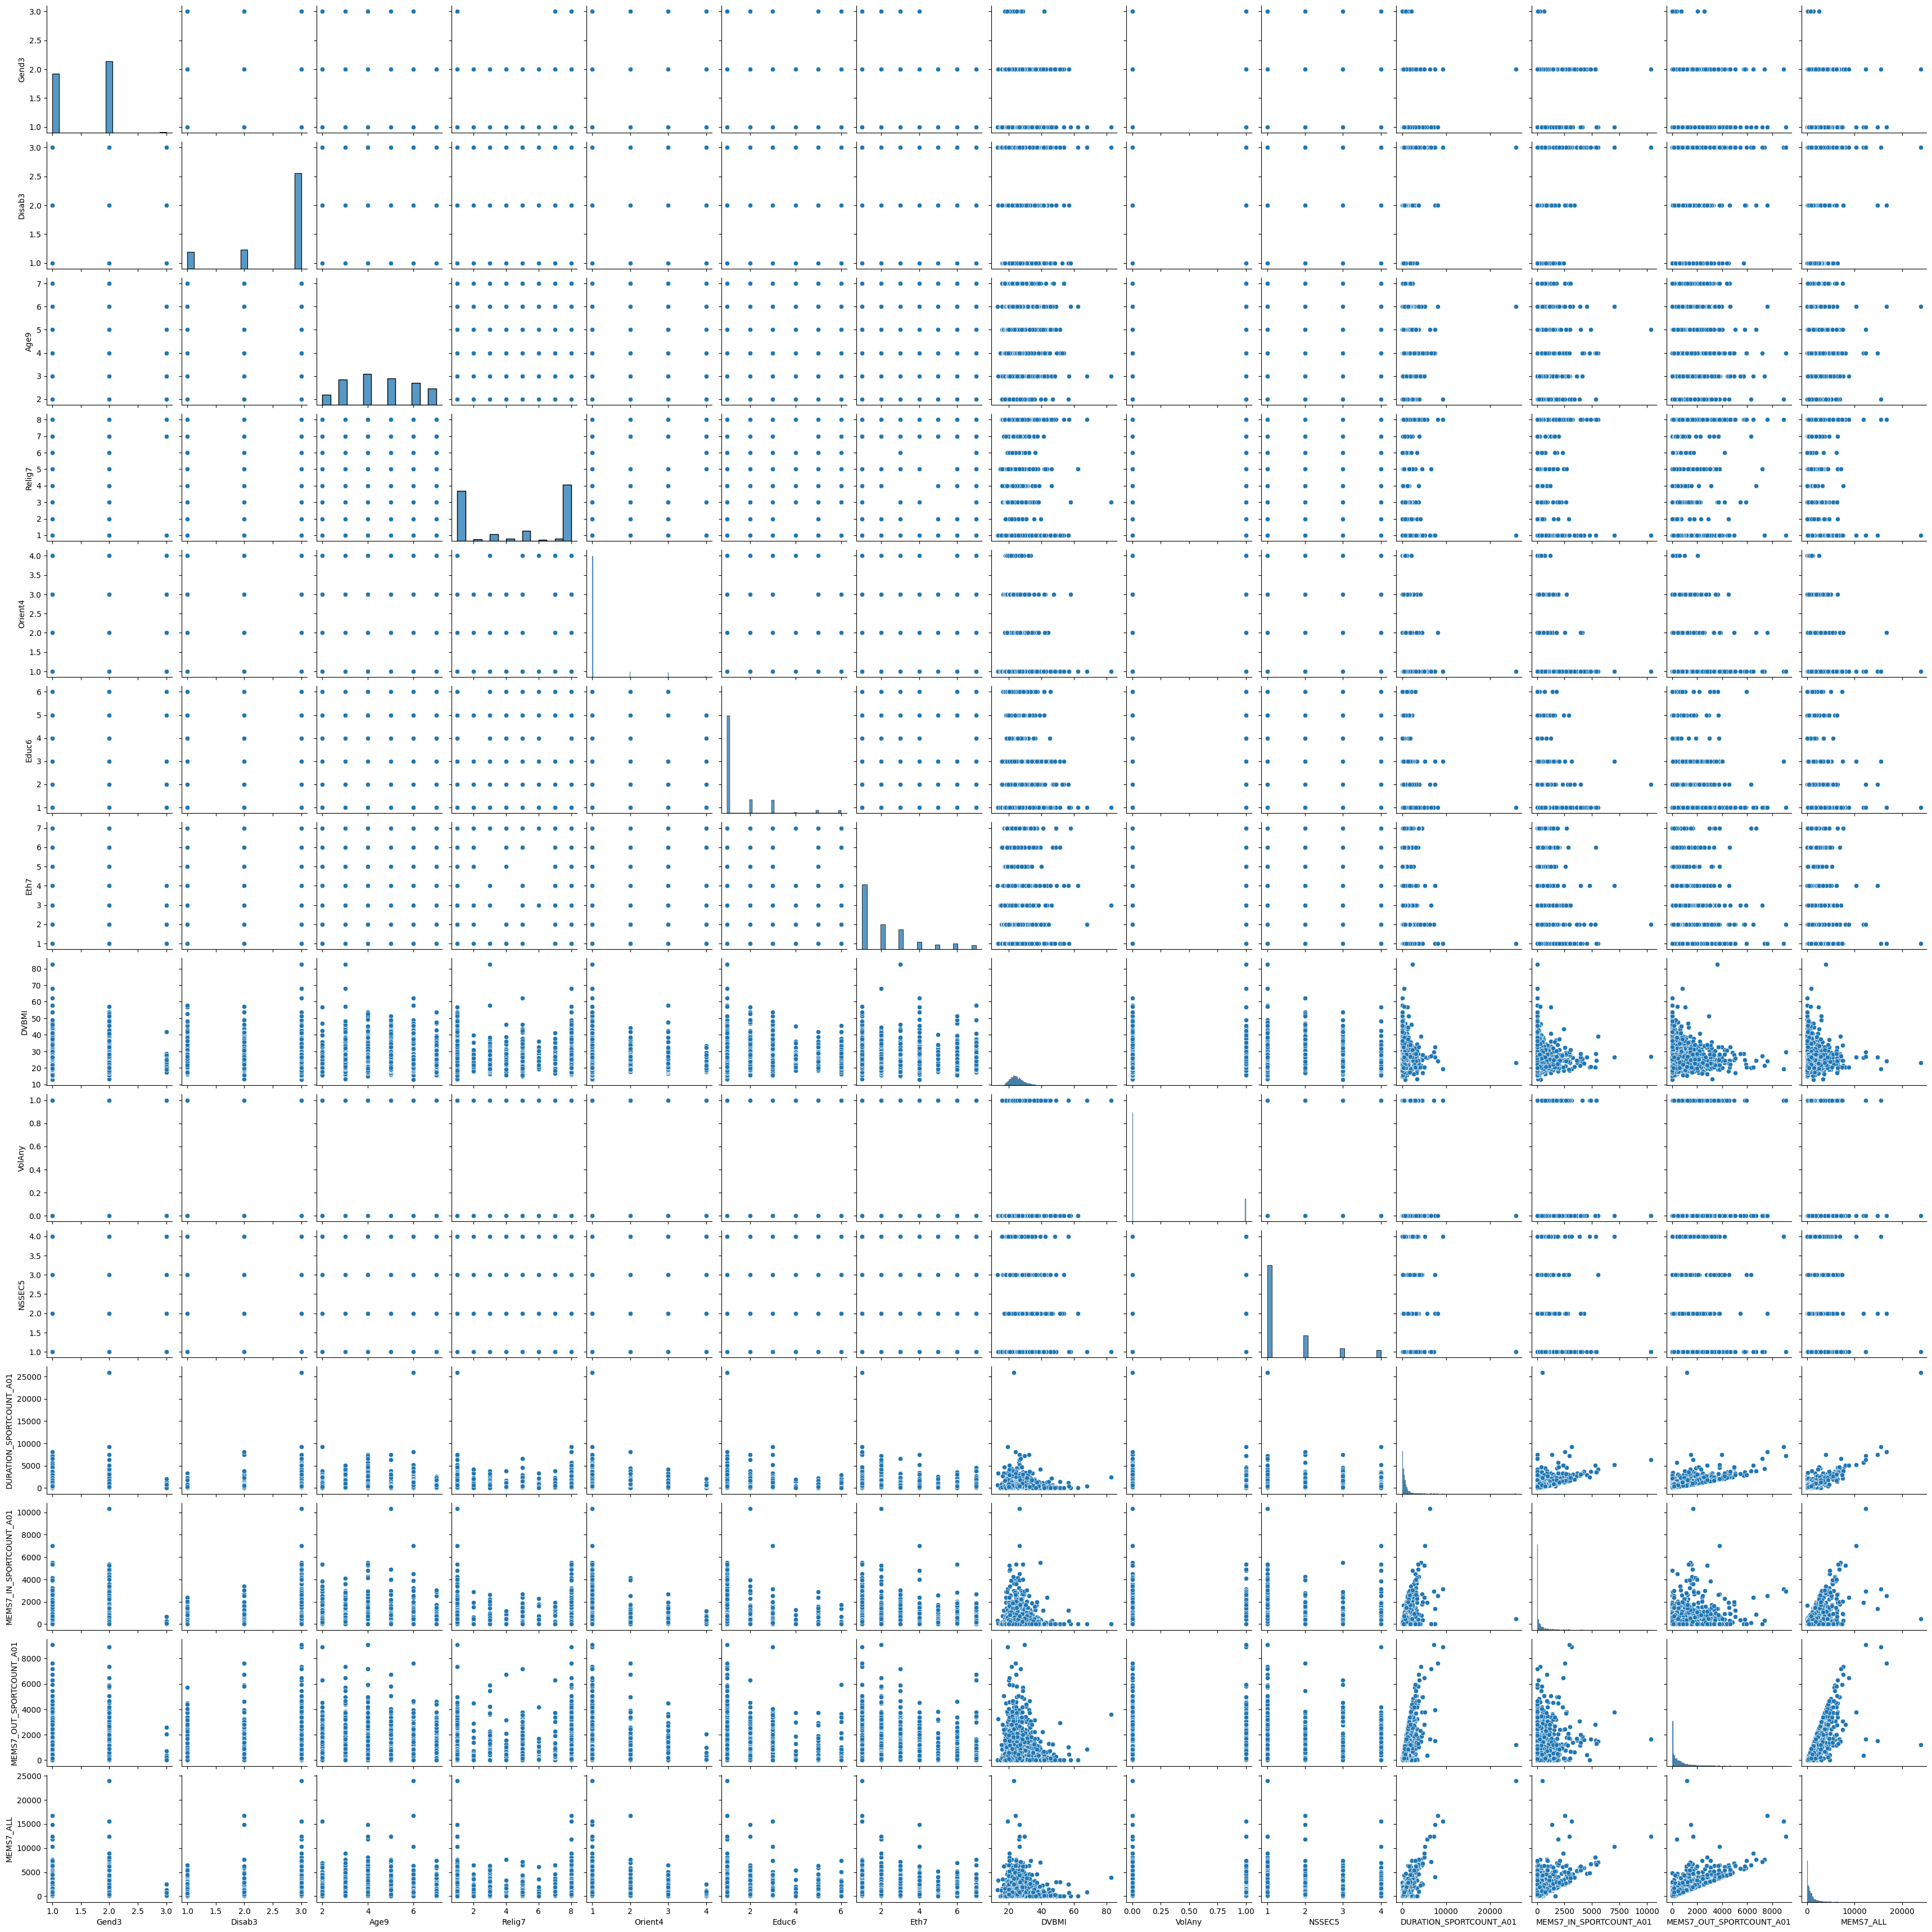

In [27]:
cols = ['Gend3', 'Disab3', 'Age9', 'Relig7', 'Orient4', 'Educ6', 'Eth7', 'DVBMI', 'VolAny', 'NSSEC5', 'DURATION_SPORTCOUNT_A01', 'MEMS7_IN_SPORTCOUNT_A01', 'MEMS7_OUT_SPORTCOUNT_A01', 'MEMS7_ALL']
sns.pairplot(
    df, 
    vars = cols
)

In [28]:
cols = ['Gend3', 'Age9', 'Educ6', 'DVBMI', 'VolAny', 'NSSEC5', 'DURATION_SPORTCOUNT_A01', 'MEMS7_IN_SPORTCOUNT_A01', 'MEMS7_OUT_SPORTCOUNT_A01', 'MEMS7_ALL']
df_corr = df[cols].corr()

<Axes: >

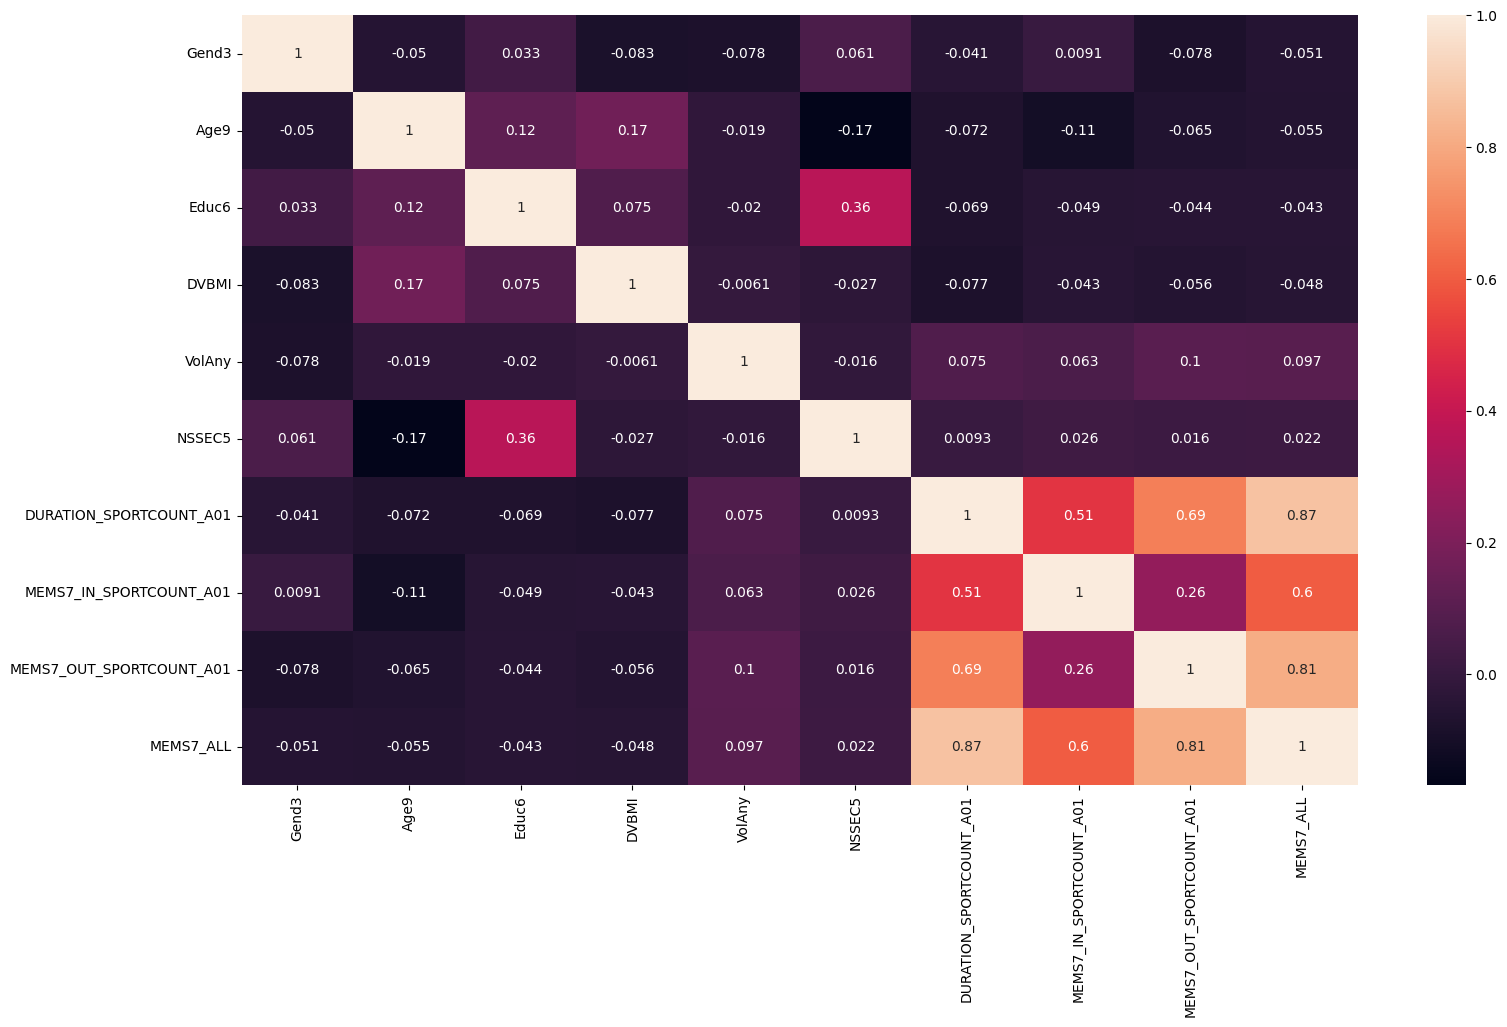

In [29]:
plt.figure(figsize=(18,10))
sns.heatmap(df_corr, annot=True)

In [30]:
cols = ['year','Gend3', 'Disab3', 'Age9', 'Relig7', 'Orient4', 'Educ6', 'Eth7', 'DVBMI', 'VolAny', 'NSSEC5', 'DURATION_SPORTCOUNT_A01', 'MEMS7_IN_SPORTCOUNT_A01', 'MEMS7_OUT_SPORTCOUNT_A01', 'MEMS7_ALL', 'MEMS7_SPORTCOUNT_A01']
df = pd.read_csv(path, usecols = cols)
df = df[df['year'] == '2022 - 2023']
df = df.dropna()

In [31]:

x = df[df['MEMS7_SPORTCOUNT_A01'] > 150]
print(len(x))
print(len(df))

2930
4266


<Axes: >

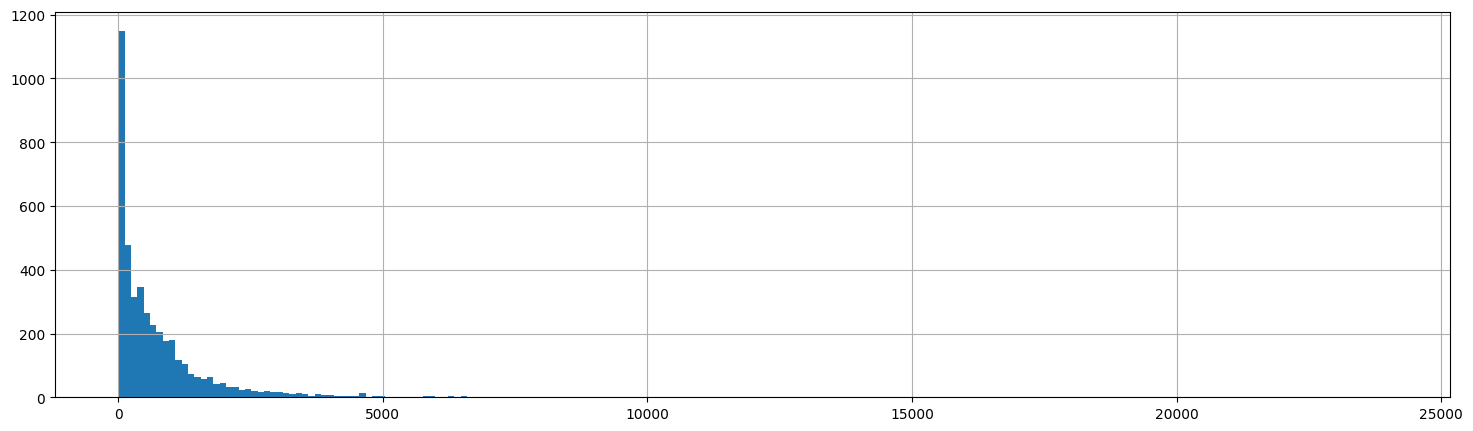

In [32]:
plt.figure(figsize=(18,5))
df['MEMS7_SPORTCOUNT_A01'].hist(bins=200)

In [33]:
x = (df['MEMS7_SPORTCOUNT_A01'] > 1000).sum()
x

np.int64(1036)

In [34]:
df_clipped = df['MEMS7_SPORTCOUNT_A01'].clip(lower = 0, upper = 5000)

<Axes: >

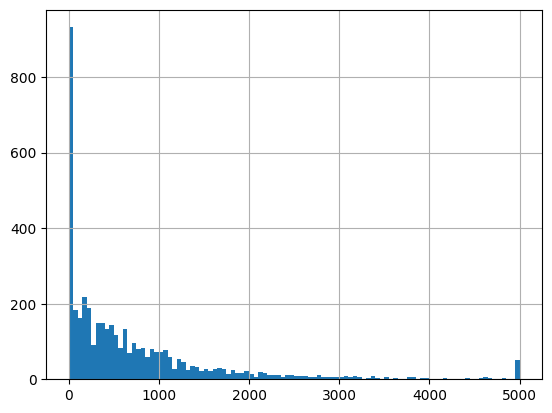

In [35]:
df_clipped.hist(bins=100)

<Axes: >

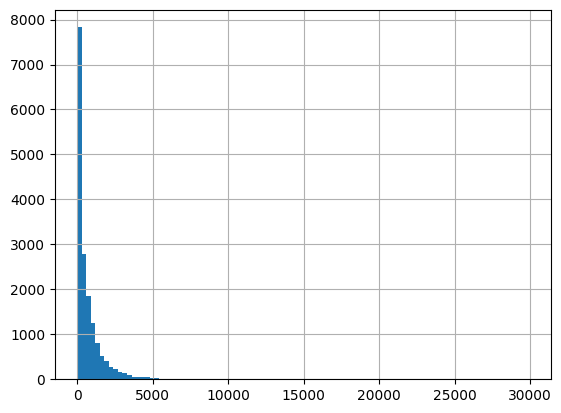

In [36]:
df = pd.read_csv(path, usecols=cols)
df = df[df['year'] == '2022 - 2023']
df['MEMS7_SPORTCOUNT_A01'].hist(bins=100)


<Axes: >

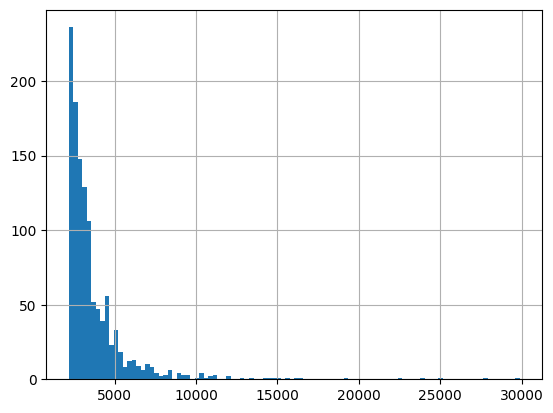

In [37]:
over_5000 = df[df['MEMS7_SPORTCOUNT_A01'] > 2160]
over_5000['MEMS7_SPORTCOUNT_A01'].hist(bins=100)

In [38]:
print(f'Over 2160: {len(over_5000)}')
print(f'Dataframe length: {len(df)}')

Over 2160: 1192
Dataframe length: 16748


In [63]:
import pyreadstat
cols = [
    'LondInOut','Gend3','Disab3','Age9', 'Relig7', 'Orient4', # Demographic variables
    'Educ6', 'Eth7', 'DVBMI', 'VolAny', 'NSSEC5',
          
    'DURATION_SPORTCOUNT_A01', 'MEMS7_IN_SPORTCOUNT_A01', 'MEMS7_OUT_SPORTCOUNT_A01', # Duration variables
    'MEMS7_ALL', 'MEMS7_SPORTCOUNT_A01', 
    
    'MEMS7_WALKLEISURE_B01', 'MEMS7_WALKTRAV_B02', 'MEMS7_CYCLEISSPORT_B03', 'MEMS7_CYCTRAV_B04', # Specific sport variables
    'MEMS7_DANCEART_B05', 'MEMS7_FITNESS_B06', 'MEMS7_SPORTTRAD_B07', 'MEMS7_GARD_B08'
    ]
path = r"C:/Masters/London Sport/9288_ActiveLifeSurvey_2022_2023/UKDA-9288-spss/spss/spss28/active_lives_survey_nov_22-23_data_year_8_shared_20250103.sav"
df, meta = pyreadstat.read_sav(path, usecols = cols)
df = df[df['LondInOut'].notna()]
for c in cols:
    if c not in df.columns:
        raise ValueError(f'Column: {c} not in df')

In [72]:
df.head()

,LondInOut,Age9,Disab3,Educ6,Eth7,Gend3,NSSEC5,Orient4,Relig7,DVBMI,...,MEMS7_CYCLEISSPORT_B03,MEMS7_CYCTRAV_B04,MEMS7_DANCEART_B05,MEMS7_FITNESS_B06,MEMS7_SPORTTRAD_B07,MEMS7_GARD_B08,MEMS7_IN_SPORTCOUNT_A01,MEMS7_OUT_SPORTCOUNT_A01,total_act,mems_def
10,1.0,5.0,2.0,1.0,1.0,2.0,1.0,NaN,NaN,21.224490,...,60.0,60.0,0.0,0.0,112.5,0.0,NaN,NaN,652.5,0.0
33,2.0,NaN,3.0,1.0,NaN,2.0,4.0,NaN,NaN,20.634515,...,0.0,0.0,0.0,360.0,240.0,0.0,NaN,NaN,615.0,0.0
52,2.0,3.0,3.0,1.0,2.0,1.0,1.0,NaN,NaN,31.013953,...,240.0,60.0,0.0,480.0,0.0,0.0,NaN,NaN,840.0,0.0
53,2.0,3.0,2.0,1.0,5.0,2.0,1.0,NaN,NaN,17.506390,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0
54,2.0,6.0,1.0,1.0,1.0,1.0,3.0,1.0,1.0,29.270718,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: >

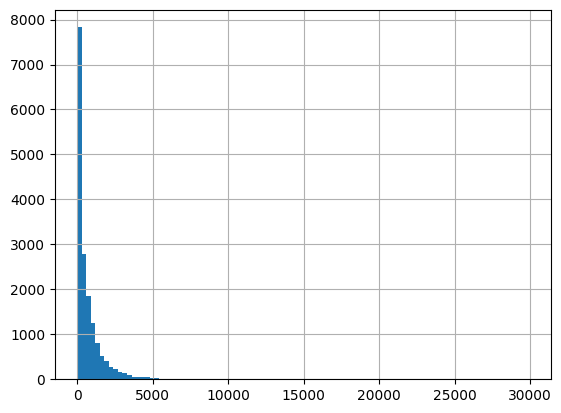

In [73]:
df['MEMS7_SPORTCOUNT_A01'].hist(bins=100)

<Axes: >

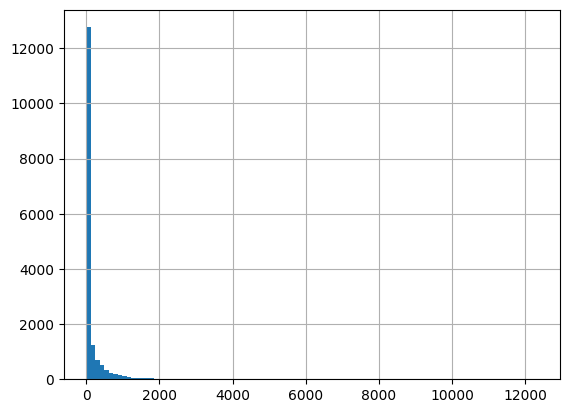

In [74]:
df['MEMS7_SPORTTRAD_B07'].hist(bins=100)

In [75]:
x = df[df['MEMS7_SPORTTRAD_B07'] > 5000]
x

,LondInOut,Age9,Disab3,Educ6,Eth7,Gend3,NSSEC5,Orient4,Relig7,DVBMI,...,MEMS7_CYCLEISSPORT_B03,MEMS7_CYCTRAV_B04,MEMS7_DANCEART_B05,MEMS7_FITNESS_B06,MEMS7_SPORTTRAD_B07,MEMS7_GARD_B08,MEMS7_IN_SPORTCOUNT_A01,MEMS7_OUT_SPORTCOUNT_A01,total_act,mems_def
564,1.0,2.0,3.0,3.0,1.0,1.0,4.0,1.0,NaN,23.846227,...,1950.0,0.0,0.0,1500.00,6030.00,0.0,NaN,NaN,11280.0,-3000.0
15477,2.0,4.0,3.0,1.0,2.0,1.0,2.0,1.0,8.0,26.315789,...,0.0,0.0,0.0,1440.00,9234.00,840.0,1920.0,360.0,11874.0,0.0
30318,2.0,2.0,1.0,1.0,NaN,1.0,1.0,NaN,8.0,NaN,...,1092.0,2160.0,1380.0,0.00,10068.00,0.0,4380.0,12660.0,19140.0,0.0
30729,2.0,2.0,3.0,2.0,3.0,1.0,1.0,1.0,5.0,NaN,...,0.0,0.0,0.0,0.00,6780.00,0.0,30.0,6780.0,6780.0,30.0
30966,1.0,5.0,NaN,NaN,NaN,1.0,4.0,1.0,NaN,NaN,...,0.0,0.0,0.0,0.00,6904.00,0.0,NaN,NaN,8824.0,0.0
45903,2.0,4.0,2.0,2.0,4.0,1.0,2.0,1.0,1.0,26.608446,...,0.0,0.0,0.0,1352.50,12320.00,0.0,1352.5,1520.0,14842.5,0.0
46036,2.0,6.0,3.0,1.0,1.0,1.0,2.0,1.0,1.0,30.497665,...,0.0,0.0,0.0,3455.00,5400.00,180.0,NaN,NaN,9735.0,0.0
62678,1.0,2.0,3.0,2.0,2.0,1.0,2.0,1.0,1.0,NaN,...,4140.0,0.0,0.0,0.00,6720.00,0.0,NaN,NaN,10860.0,0.0
62935,1.0,2.0,3.0,3.0,1.0,2.0,4.0,1.0,8.0,19.442101,...,0.0,0.0,1464.0,2655.00,8760.00,0.0,3144.0,8900.0,15539.0,0.0
77214,2.0,3.0,3.0,1.0,3.0,2.0,1.0,1.0,7.0,21.349928,...,0.0,0.0,0.0,0.00,5880.00,0.0,NaN,NaN,9240.0,0.0


In [76]:
x = df[df['MEMS7_FITNESS_B06'] > 10000]
len(x)

6

<Axes: >

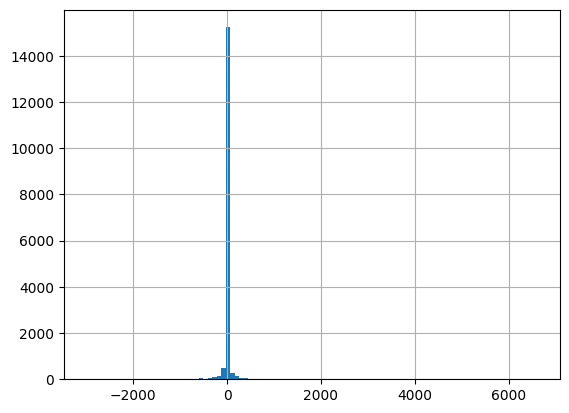

In [77]:
df['total_act'] = (
    df['MEMS7_WALKLEISURE_B01'] + df['MEMS7_WALKTRAV_B02'] + df['MEMS7_CYCLEISSPORT_B03'] + df['MEMS7_CYCTRAV_B04'] +
    df['MEMS7_DANCEART_B05'] + df['MEMS7_FITNESS_B06'] + df['MEMS7_SPORTTRAD_B07'] + df['MEMS7_GARD_B08']
)
df['mems_def'] = (df['MEMS7_ALL'] - df['total_act'])
df['mems_def'].hist(bins=100)  

In [ ]:
print(f"People whos MEMS_ALL is LESS than the sum of sport at B level: {len(df[df['mems_def'] < 0])}")
print(f"People whos MEMS_ALL is MORE than the sum of sport at B level: {len(df[df['mems_def'] > 0])}")

People whos MEMS_SPORTCOUNT is LESS than the sum of sport at B level: 1014
People whos MEMS_SPORTCOUNT is MORE than the sum of sport at B level: 989


<Axes: >

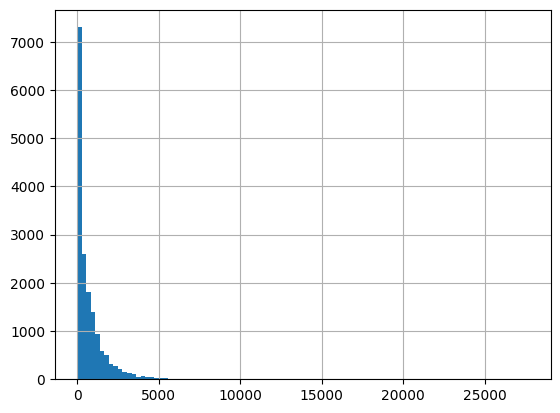

In [78]:
df['total_act'].hist(bins=100)

In [81]:
under_150 = df[df['MEMS7_SPORTCOUNT_A01'] < 150]
over_150 = df[df['MEMS7_SPORTCOUNT_A01'] > 150]
print(f'Proportion who do over 150mins pw: {len(over_150)/len(df)}')
print(f'Proportion who do less than 150min pw: {len(under_150)/len(df)}')

Proportion who do over 150mins pw: 0.6294482923334129
Proportion who do less than 150min pw: 0.3571769763553857


In [82]:
over_150['MEMS7_SPORTCOUNT_A01'].mean()

np.float64(1093.228822804022)

In [83]:
df['MEMS7_SPORTCOUNT_A01'].mean()

np.float64(699.3042303558634)

In [1]:
import os
os.getcwd()

'c:\\Users\\fergu\\Documents\\GitHub\\london_sport2\\exploration\\determinants_eda'

In [1]:
from load_data import get_data
df, meta = get_data()
df.head()

Data Collected...
Data Shape: (16748, 116)


,wt_final,wt_time,xStrata,Reg9,LondInOut,LA_2023,Age9,nadult,nchild,Disab3,...,MONTHS_12_BASESOFTBALL_F13,MONTHS_12_LACROSSE_F14,MONTHS_12_GOALBALL_F15,MONTHS_12_HANDBALL_F16,MEMS7_IN_SPORTCOUNT_A01,MEMS7_OUT_SPORTCOUNT_A01,WHOWITHA_SPORTCOUNT_A01,WHOWITHB_SPORTCOUNT_A01,WHOWITHC_SPORTCOUNT_A01,WHOWITHD_SPORTCOUNT_A01
10,0.589497,0.476685,117.0,3.0,1.0,114.0,5.0,1.0,0.0,2.0,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0
33,0.962646,1.165975,129.0,3.0,2.0,126.0,NaN,1.0,0.0,3.0,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0
52,3.840907,3.882306,9.0,3.0,2.0,9.0,3.0,2.0,1.0,3.0,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0
53,1.506097,1.525295,9.0,3.0,2.0,9.0,3.0,1.0,0.0,2.0,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0
54,1.656646,1.347375,132.0,3.0,2.0,129.0,6.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
